Review Project Setup and Data Generaion
## FPL Revenue Collections Risk Analytics
Purpose: Setup the environment, load raw datasets, and generate a synthetic utility customer dataset that mirrors collection workflow and NextEra Energy

In [5]:
import importlib
import sys

required = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "sklearn", "imblearn", "scipy", "openpyxl"
]

print(f"Python version: {sys.version.split()[0]}\n")
print("Library              Status")
print("-" * 35)

for lib in required:
    try:
        mod = importlib.import_module(lib)
        ver = str(getattr(mod, "__version__", "ok"))
        print(f"  {lib.ljust(18)} OK  {ver}")
    except ImportError:
        print(f"  {lib.ljust(18)} NOT INSTALLED")

Python version: 3.9.13

Library              Status
-----------------------------------
  pandas             OK  2.2.2
  numpy              OK  1.26.4
  matplotlib         OK  3.8.4
  seaborn            OK  0.13.2
  sklearn            OK  1.4.2
  imblearn           OK  0.12.2
  scipy              OK  1.13.0
  openpyxl           OK  3.1.2


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")  #shut up yellow warnings!!!
np.random.seed(42)

# Paths
RAW_DIR       = "../data/raw"
PROCESSED_DIR = "../data/processed"
FIGURES_DIR   = "../reports/figures"

# Directories to create
for path in [RAW_DIR, PROCESSED_DIR, FIGURES_DIR]:
    os.makedirs(path, exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


## LOADING UCI DATASET

In [7]:
UCI_FILE = os.path.join(RAW_DIR, "UCI dataset.xls")

uci_df = pd.read_excel(UCI_FILE, header=1)

print(f"Dataset loaded: {uci_df.shape[0]} rows, {uci_df.shape[1]} columns")
print(f"Columns: {list(uci_df.columns)}")

Dataset loaded: 30000 rows, 25 columns
Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [8]:
uci_df.columns = uci_df.columns.str.strip().str.lower().str.replace( " ", "_")

uci_df.rename(columns={"default_payment_next_month": "delinquent"}, inplace=True)

print(f"Columns: {list(uci_df.columns)}")

Columns: ['id', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'delinquent']


In [22]:
print("=" * 45)
print(" UCI DATASET PROFILE")
print("=" * 45)
print(f" Rows          : {uci_df.shape[0]:,}")
print(f" Columns       : {uci_df.shape[1]}")
print(f" Null values   : {uci_df.isnull().sum().sum()}")  #Gotta remember the second sum to add the count of nulls per column
print(f" Duplicates    : {uci_df.duplicated().sum()}")
print("=" * 45)

#Delinquency rate
total = len(uci_df)
delinquent = uci_df["delinquent"].sum()

print(f"\n Delinquent accounts     : {delinquent:,}")
print(f"\n Non-Delinquent accounts : {total - delinquent:,}")
print(f"\n Delinquency Rate        : {delinquent/total*100:.1f}%")

uci_df.head()

 UCI DATASET PROFILE
 Rows          : 30,000
 Columns       : 25
 Null values   : 0
 Duplicates    : 0

 Delinquent accounts     : 6,636

 Non-Delinquent accounts : 23,364

 Delinquency Rate        : 22.1%


,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,delinquent
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Generate Synthetic utility customer dataset

In [28]:
N = 1000

#Credit Segment-> A is lowest risk
segments = np.random.choice(["A", "B", "C", "D"], size = N, p=[0.30, 0.35, 0.25, 0.10])

seg_map     = {"A":0, "B": 1, "C": 2, "D": 3} #I'llconvert the segments to #
seg_numeric = np.array([seg_map[s] for s in segments])

# A/C age in months 
# Newer customers -> higher risk

# Use .clip so no -ve # or #s over 10,000

account_age = np.clip(     # Seg A (seg=0): Avg a/c age = 72 months
    np.random.normal(loc=72 - seg_numeric * 8, scale=24), 1, 240).astype(int)

avg_bill = np.clip(
    np.random.normal(loc=130 + seg_numeric * 15, scale=34), 40, 500).round(2)

# Prior delinquencies in 24 hr
prior_delinq = np.clip(    # Seg A (lambda=0) -> Avg 0 prior delinquencies
    np.random.poisson(lam=seg_numeric * 0.9), 0, 8).astype(int)
                            # the higher the lambda, the more frequently the event occured 

# Current days past due
days_past_due = np.clip(
    np.random.exponential(scale=seg_numeric * 18 + 1), 0, 180).round(0).astype(int)

# AutoPay enrollment - higher risk customers less likely to enroll
autopay_prob = np.array([0.65 - seg_numeric[i] * 0.12 for i in range(N)])
autopay      = (np.random.rand(N) < autopay_prob).astype(int)

# Outstanding balance owed
balance_owed = np.clip(
    avg_bill * (days_past_due / 30 + 0.5), 0, 3000
).round(2)

# Target variable - delinquent (1) or current (0)
delinq_score = (
      0.04  * seg_numeric
    + 0.015 * prior_delinq
    + 0.006 * days_past_due
    - 0.003 * account_age / 12
    + 0.008 * (1 - autopay)
)
delinq_prob = 1 / (1 + np.exp(-delinq_score * 3 + 1.5))
delinquent  = (np.random.rand(N) < delinq_prob).astype(int)

# Assemble everything into a DataFrame
synthetic_df = pd.DataFrame({
    "customer_id"        : [f"FPL-{100000 + i}" for i in range(N)],
    "account_age_months" : account_age,
    "credit_segment"     : segments,
    "avg_monthly_bill"   : avg_bill,
    "autopay_enrolled"   : autopay,
    "prior_delinquencies": prior_delinq,
    "days_past_due"      : days_past_due,
    "balance_owed"       : balance_owed,
    "delinquent"         : delinquent
})

print(f"Synthetic dataset created: {synthetic_df.shape[0]} rows, {synthetic_df.shape[1]} columns")
print(f"Delinquency rate: {synthetic_df['delinquent'].mean()*100:.1f}%")
synthetic_df.head()

Synthetic dataset created: 1000 rows, 9 columns
Delinquency rate: 30.2%


,customer_id,account_age_months,credit_segment,avg_monthly_bill,autopay_enrolled,prior_delinquencies,days_past_due,balance_owed,delinquent
0,FPL-100000,76,A,40.00,1,0,0,20.00,1
1,FPL-100001,37,C,143.46,0,2,62,368.21,0
2,FPL-100002,94,B,97.94,1,0,13,91.41,0
3,FPL-100003,69,B,117.81,1,2,3,70.69,1
4,FPL-100004,95,A,125.08,0,0,1,66.71,0


## Visualization

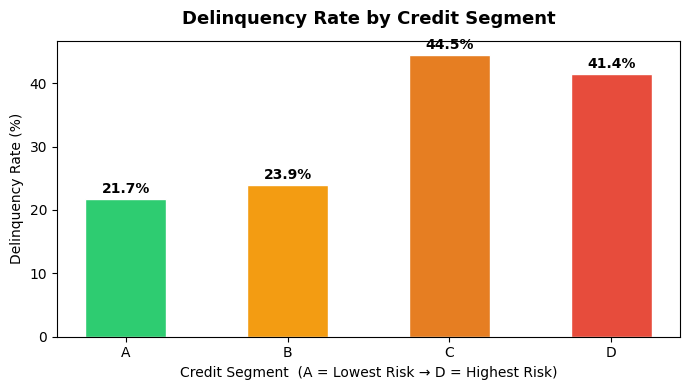

Chart saved to reports/figures/


In [32]:
delinq_by_seg = (
    synthetic_df.groupby("credit_segment")["delinquent"]
    .mean()
    .reset_index() # after the groupby, result has a special index. Reset it back to regular numbered index
    .sort_values("credit_segment")
)

# Setting up the chart
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]

ax.bar(
    delinq_by_seg["credit_segment"],
    delinq_by_seg["delinquent"] * 100,
    color=colors,
    edgecolor="white",
    width=0.5
)

# Labels and title
ax.set_title("Delinquency Rate by Credit Segment", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Credit Segment  (A = Lowest Risk → D = Highest Risk)")
ax.set_ylabel("Delinquency Rate (%)")

# Add percentage labels on top of each bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

plt.tight_layout() #adjust spacing so nothing cuts off
plt.savefig(os.path.join(FIGURES_DIR, "delinquency_by_segment.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to reports/figures/")

In [34]:
# Save the dataset to the Processed folder

UCI_OUT = os.path.join(PROCESSED_DIR, "uci_credit_default_cleaned.csv")
uci_df.to_csv(UCI_OUT, index=False)
print(f"UCI dataset saved: {UCI_OUT}")

UCI dataset saved: ../data/processed/uci_credit_default_cleaned.csv


### Key observations
- THere were **0 null values** and **0 duplicates** in the dataset
- Delinquency rate is **30.2%**- so, the model has enough positive cases to learn meaningful patterns without severe class imbalance

### EDA, Delinquency patterns, correlation heatmap

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED_DIR = "../data/processed"
FIGURES_DIR   = "../reports/figures"

# Loading the cleaned UCI dataset
df = pd.read_csv(os.path.join(PROCESSED_DIR, "uci_credit_default_cleaned.csv"))

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Delinquency rate: {df['delinquent'].mean()*100:.1f}%")
df.head()

Dataset loaded: 30,000 rows, 25 columns
Delinquency rate: 22.1%


,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,delinquent
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


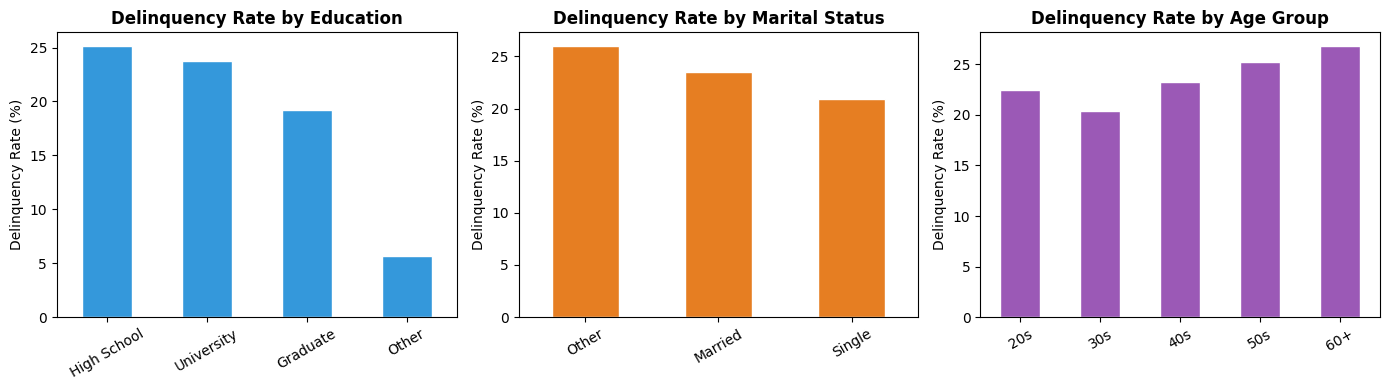

Chart saved.


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Delinquency by Education
edu_map = {1: "Graduate", 2: "University", 3: "High School", 4: "Other"}
df["education_label"] = df["education"].map(edu_map)
edu_rate = df.groupby("education_label")["delinquent"].mean() * 100
edu_rate.sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], color="#3498db", edgecolor="white"
)
axes[0].set_title("Delinquency Rate by Education", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Delinquency Rate (%)")
axes[0].tick_params(axis="x", rotation=30)

# Plot 2: Delinquency by Marriage Status
mar_map = {1: "Married", 2: "Single", 3: "Other"}
df["marriage_label"] = df["marriage"].map(mar_map)
mar_rate = df.groupby("marriage_label")["delinquent"].mean() * 100
mar_rate.sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color="#e67e22", edgecolor="white"
)
axes[1].set_title("Delinquency Rate by Marital Status", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Delinquency Rate (%)")
axes[1].tick_params(axis="x", rotation=30)

# Plot 3: Delinquency by Age Group
df["age_group"] = pd.cut(df["age"], bins=[20, 30, 40, 50, 60, 80],
                          labels=["20s", "30s", "40s", "50s", "60+"])
age_rate = df.groupby("age_group")["delinquent"].mean() * 100
age_rate.plot(kind="bar", ax=axes[2], color="#9b59b6", edgecolor="white")
axes[2].set_title("Delinquency Rate by Age Group", fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Delinquency Rate (%)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "delinquency_by_demographics.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

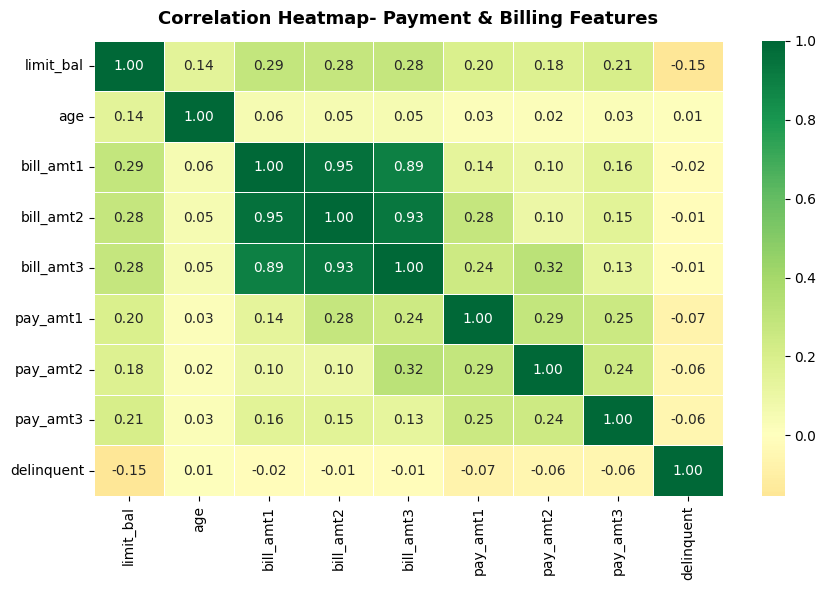

Heatmap saved


In [45]:
cols = ["limit_bal", "age", "bill_amt1", "bill_amt2", "bill_amt3",
        "pay_amt1", "pay_amt2", "pay_amt3", "delinquent"]

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn", # Rd- negative corr, Yl- near 0, Gr- Positive corr
    center=0,      # color scale anchored at 0
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Heatmap- Payment & Billing Features",
             fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "correlation_heatmap.png"),
           dpi=150, bbox_inches="tight")

plt.show()
print("Heatmap saved")

### Key Findings

- **High School educated customers** show the highest delinquency rate (about 25%), 
  while "Other" education category shows the lowest ( about 5%)
- **Married customers** show slightly higher delinquency than Single customers — 
  marital status alone is not a strong differentiator
- **Older customers (60+) show the highest delinquency rate** ( about 26%) while 
  customers in their 30s show the lowest ( about 20%)
- **Credit limit (limit_bal)** is the strongest predictor in the heatmap 
  at -0.15 — higher limits associate with lower delinquency
- **Bill amounts are highly collinear** (0.89–0.95) — redundant features 
  that will be reduced in feature engineering